In [1]:
# Diving into RNNs ( designed based as mentioned here : {sutskever et al. 2011} https://icml.cc/2011/papers/524_icmlpaper.pdf )

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open("names.txt", 'r').read().splitlines()

In [3]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
print(itos)

vocab_size = len(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# building the dataset

def build_dataset(words):
    block_size = 3 # context length
    X, Y = [], []
    for w in words:
    
        # print(w)
        context = [0] * block_size
        for ch in w +'.' :
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [60]:
# MLP revisited

# Changes:

# S. 1
# bais_2 * 0 -> at init, we don't want to add random values to logits
# weight_2 * 0.01 -> to scale down on W2, proportionally sacles down logits on init
# which get rids of higher false confidence

# S. 2
# bais_1 * 0.01 -> to bring hpreact closer to 0, while having some entropy (* 0 is also fine)
# weight_1 * 0.1 (or any > 0) -> to bring hpreact closer to 0

# how do we come up with these 0, 0.1, 0.01 etc.?
# See below

# why not weight also 0??
# 



n_embed = 10 # the dim of the character embedding vector
n_hidded = 200 # the num of neuron in hidded layer

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed),             generator=g)
W1 = torch.randn((n_embed * block_size, n_hidded), generator=g) * 0.2
b1 = torch.randn(n_hidded,                         generator=g) * 0.01
W2 = torch.randn((n_hidded, vocab_size),           generator=g) * 0.01
b2 = torch.randn(vocab_size,                       generator=g) * 0

parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # num parameters in total
for p in parameters:
    p.requires_grad = True

tensor(-0.0224) tensor(0.9975)
tensor(-0.0003) tensor(0.9932)


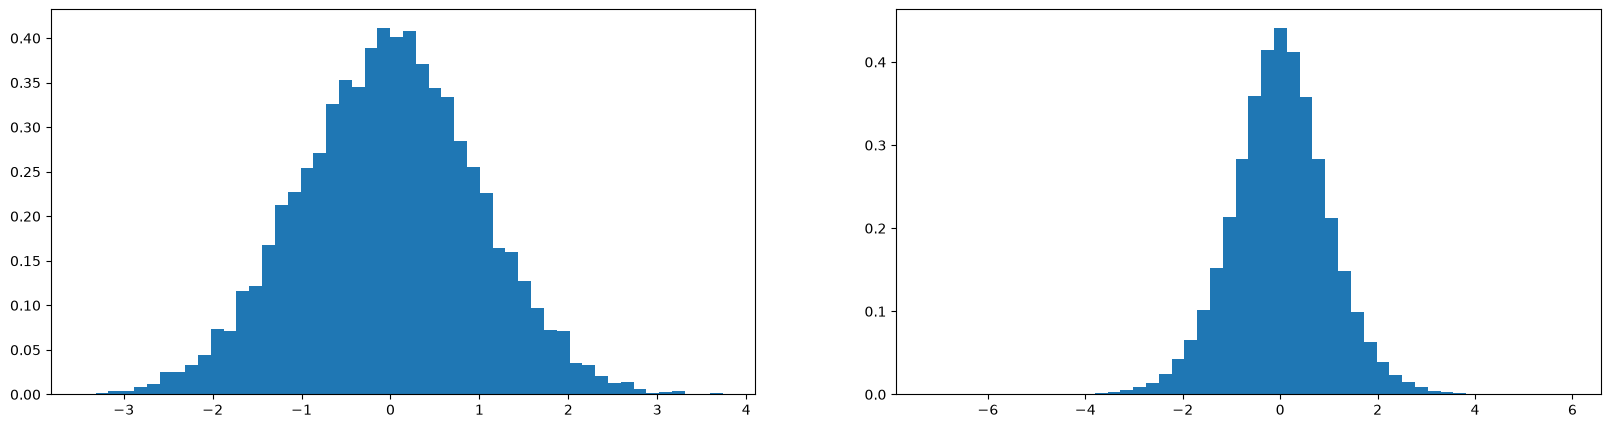

In [65]:
# how do we come up with these 0, 0.1, 0.01 etc.?

# what we want - we want the st. d. to remain relatively same before or after activations to
# preserve the disribution while remaining a gaussian

# if we * w with 
    # 1. > 1 ->  st. d. increases
    # 2. < 1 -> st. d. decreases
    # as we want a decrease we mult by a scalar < 1. but what exactly??

# mathematically, it is seen that we need to divide the w, by sqrt of fan_in (number of inputs)

# the scaling factor for init have been deeply studied and the most often cited paper is by
# Kaiming He, .. where they study on CNN for ReLU. (https://arxiv.org/pdf/1502.01852)

# pytorch has a function for this as well:
    # torch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='tanh or ..')
    # https://docs.pytorch.org/docs/2.14/nn.init.html#torch.nn.init.kaiming_normal_

x = torch.randn(1000, 10) # std -> approx 1
# as fan_in = 10
w = torch.randn(10, 200) / 10**0.5
y = x @ w                 # std -> without scaling - > 1 (relative)
                          # std -> with scaling w - approx 1
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [61]:
# for details of implementation, see Micrograd2.ipynb

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    #forward pass
    emb = C[Xb] # embed the char into vectors
    embcat = emb.view(emb.shape[0], -1) # concat the vectors
    hpreact = embcat @ W1 + b1 # hidded layer pre-activation
    h = torch.tanh(hpreact)   # [-1, 1] due to tanh (hiddden layer)
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000: 3.3135
  10000/ 200000: 2.1648
  20000/ 200000: 2.3061
  30000/ 200000: 2.4541
  40000/ 200000: 1.9787
  50000/ 200000: 2.2930
  60000/ 200000: 2.4232
  70000/ 200000: 2.0680
  80000/ 200000: 2.3095
  90000/ 200000: 2.1207
 100000/ 200000: 1.8269
 110000/ 200000: 2.2045
 120000/ 200000: 1.9797
 130000/ 200000: 2.3946
 140000/ 200000: 2.1000
 150000/ 200000: 2.1948
 160000/ 200000: 1.8619
 170000/ 200000: 1.7809
 180000/ 200000: 1.9673
 190000/ 200000: 1.8295


In [56]:
# S 1. -ve log probability of 1/27

# -torch.tensor(1/27.0).log() # expected init loss

# one way to get uniform prob is having the initial logits to be all same i.e. all 0 (prefered)
# or other integer

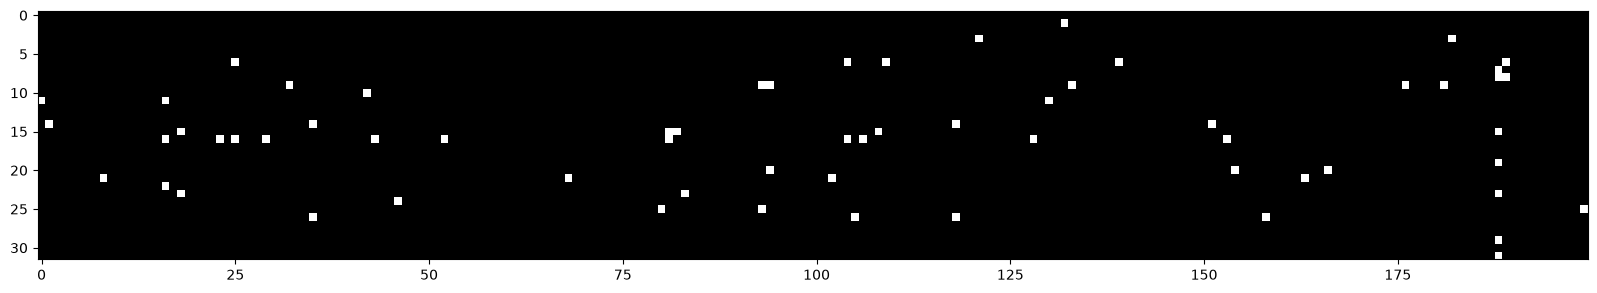

In [57]:
# S 2. shows how may neurons are > 0.99 (white for true; black for false)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

# if there is any column( of 200 ) that is all white, 
# then it is a dead neuron and will never learn

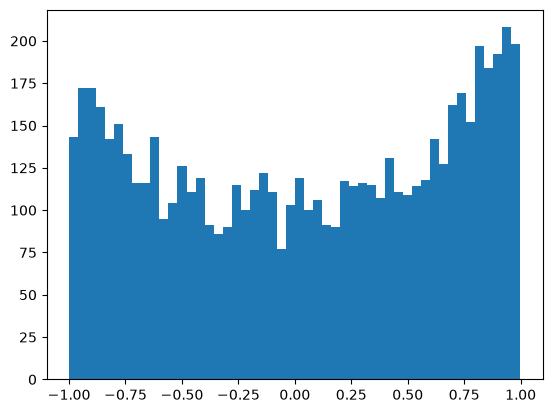

In [58]:
# S 2.
plt.hist(h.view(-1).tolist(), 50); # too many +1 and -1, why? see below

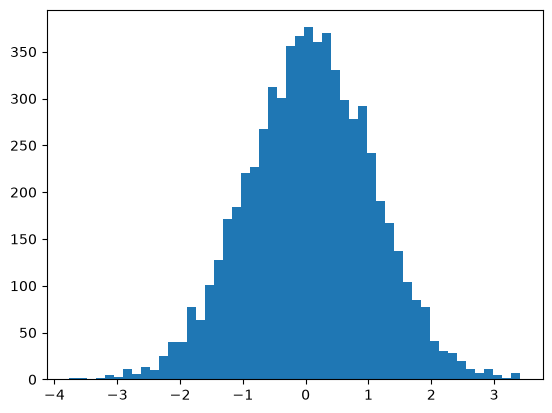

In [59]:
# S 2.
plt.hist(hpreact.view(-1).tolist(), 50); # too many pre-activations higher or lower than 0

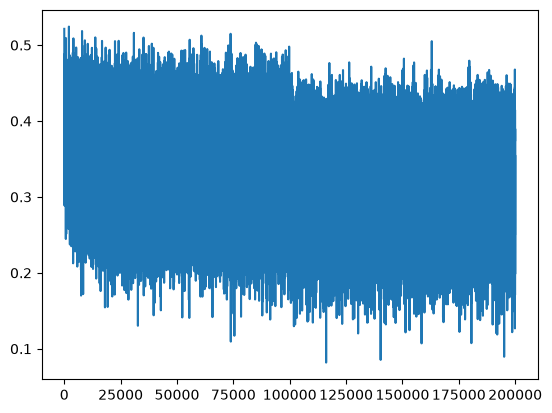

In [37]:
plt.plot(lossi)

In [38]:
@torch.no_grad() # disables gradient tracking

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]  # split will be used to index
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size) 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.069589138031006
val 2.1310746669769287


In [12]:
# sampling 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # all .'s
    while True:
        emb = C[torch.tensor([context])] # (1, block_size , d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carlah.
amori.
kahlim.
shreet.
khalayslee.
zhube.
den.
art.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quinthoron.
marianni.
wanell.
dearynix.
kael.
dura.


In [ ]:
# STARTING LOSS:
#     train: 2.124538
#     val: 2.16819

# Scritnization (part 3 begins)

# 1. Initialization :
    # as we can see the begining loss is 27.--, which is way to high. So, we can infer that
    # model is not properly configured at init.
    # how to calculate expected loss, see S 1.
    # as there is no training done, we can expect that equal probability will be assigned to any 
    # of the 27 char.
    
    # benifit of having better initilization:
        # more time spent on actual optimization of network, as seen above (lower loss)

# LOSS AFTER fixing this:
#     train: 2.07
#     val : 2.13

In [ ]:
# 2. the activated values of hidden layer on INITILIAZATION:
    # as seen in above histograms, most of the activated values are either 1 or -1.
    # and this creates a problem during back prop

    # to understand this we need to see the backward pass through tanh
    # :- (1 - tanh(x)**2) * out.grad
    #     now if we see the local grad - if tanh(x) is 1 or -1, the local grad becomes 0.
    #     i.e. the gradient of this node and any previous now will be 0 henceforth.
    #     this is due to 1 and -1 being in the flat tails for the tanh graph

    # prop of tanh for gradient:
    #     during Back prob - a tanh node can either have no effect on incomming out.grad if
    #         tanh(x) == 0
    #         or 
    #     can make it small we i.e. if tanh(x) = [-1, 0) U (0, 1] {grad becomes 0 at 1 ot -1)

    # we do not want to many +1 or -1 on init activation, and no dead neuron
    # ino our case, we have many +- 1's 

# LOSS AFTER fixing this:
#     train: 2.0355
#     val: 2.1026